In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
data = {
    "Study_Hours": [2,3,4,5,6,7,8],
    "Attendance": [60,65,70,75,80,85,90],
    "Previous_Score": [50,55,60,70,75,80,85],
    "Final_Marks": [55,60,65,72,80,88,94]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

Dataset:
   Study_Hours  Attendance  Previous_Score  Final_Marks
0            2          60              50           55
1            3          65              55           60
2            4          70              60           65
3            5          75              70           72
4            6          80              75           80
5            7          85              80           88
6            8          90              85           94



Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     7 non-null      int64
 1   Attendance      7 non-null      int64
 2   Previous_Score  7 non-null      int64
 3   Final_Marks     7 non-null      int64
dtypes: int64(4)
memory usage: 356.0 bytes
None

Statistical Summary:
       Study_Hours  Attendance  Previous_Score  Final_Marks
count     7.000000    7.000000        7.000000     7.000000
mean      5.000000   75.000000       67.857143    73.428571
std       2.160247   10.801234       13.183684    14.558584
min       2.000000   60.000000       50.000000    55.000000
25%       3.500000   67.500000       57.500000    62.500000
50%       5.000000   75.000000       70.000000    72.000000
75%       6.500000   82.500000       77.500000    84.000000
max       8.000000   90.000000       85.000000    94.000000


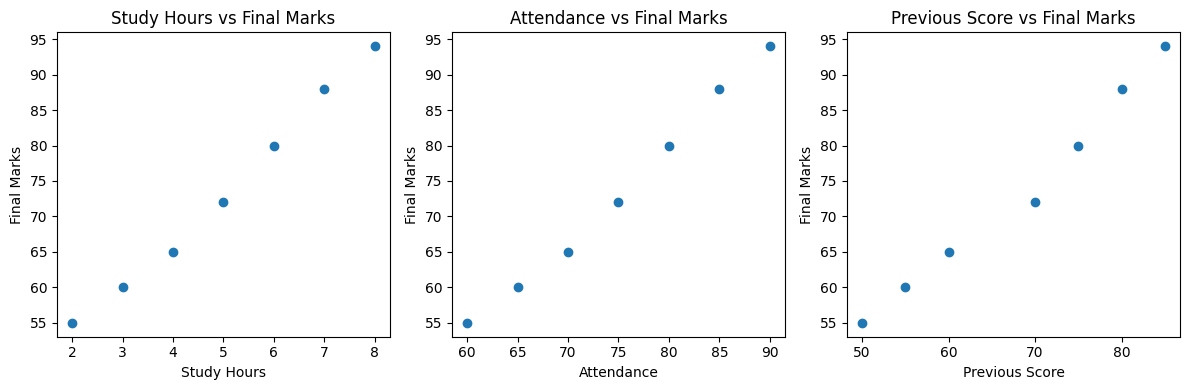

In [3]:
print("\nBasic Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df['Study_Hours'], df['Final_Marks'])
plt.title('Study Hours vs Final Marks')
plt.xlabel('Study Hours')
plt.ylabel('Final Marks')

plt.subplot(1,3,2)
plt.scatter(df['Attendance'], df['Final_Marks'])
plt.title('Attendance vs Final Marks')
plt.xlabel('Attendance')
plt.ylabel('Final Marks')

plt.subplot(1,3,3)
plt.scatter(df['Previous_Score'], df['Final_Marks'])
plt.title('Previous Score vs Final Marks')
plt.xlabel('Previous Score')
plt.ylabel('Final Marks')

plt.tight_layout()
plt.show()

In [4]:
print("\nCorrelation Matrix:")
print(df.corr())


Correlation Matrix:
                Study_Hours  Attendance  Previous_Score  Final_Marks
Study_Hours        1.000000    1.000000        0.994850     0.996286
Attendance         1.000000    1.000000        0.994850     0.996286
Previous_Score     0.994850    0.994850        1.000000     0.991155
Final_Marks        0.996286    0.996286        0.991155     1.000000


In [5]:
X = df[["Study_Hours", "Attendance", "Previous_Score"]]
y = df["Final_Marks"]

model = LinearRegression()
model.fit(X, y)

print("\nModel Trained Successfully")


Model Trained Successfully


In [6]:
new_data = [[6,82,78]]
prediction = model.predict(new_data)
print("\nPredicted Final Marks:")
print(prediction[0])


Predicted Final Marks:
82.72527472527473


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")

feature_names = X.columns

for feature, coef in zip(feature_names, model.coef_):
    print(f"{feature}: {coef}")


Intercept:
-24.703296703296687

Coefficients:
Study_Hours: 0.2582417582417582
Attendance: 1.291208791208791
Previous_Score: 0.0


In [8]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

print("\nFeature Impact:")
print(coef_df)

most_impact = coef_df.loc[
    coef_df["Coefficient"].abs().idxmax()
]

print("\nMost Influential Feature:")
print(most_impact["Feature"])


Feature Impact:
          Feature  Coefficient
0     Study_Hours     0.258242
1      Attendance     1.291209
2  Previous_Score     0.000000

Most Influential Feature:
Attendance
